In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import pandas as pd

df = pd.read_csv('../Daily_Fuel_Monitoring.csv')

df.head()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

,Date,Opening Balance,Actual Opening Balance,Daily Consumption,Closing Balance,Actual Closing Balance,System Closing Balance,Difference
0,1/1/2025,40000,39953,574,39426,39355,39426,71
1,2/1/2025,39426,39723,535,38891,38911,38891,-20
2,3/1/2025,38891,38792,368,38523,38411,38523,112
3,4/1/2025,38523,38612,220,38303,38197,38303,106
4,5/1/2025,38303,38461,878,37425,37297,37425,128


In [1]:
# Import required libraries

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# Set style for better visualization

plt.style.use('ggplot')
 

In [3]:
# Load dataset
import pandas as pd

df = pd.read_csv('../Daily_Fuel_Monitoring.csv')

df.head()

,Date,Opening Balance,Actual Opening Balance,Daily Consumption,Closing Balance,Actual Closing Balance,System Closing Balance,Difference
0,1/1/2025,40000,39953,574,39426,39355,39426,71
1,2/1/2025,39426,39723,535,38891,38911,38891,-20
2,3/1/2025,38891,38792,368,38523,38411,38523,112
3,4/1/2025,38523,38612,220,38303,38197,38303,106
4,5/1/2025,38303,38461,878,37425,37297,37425,128


In [4]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Date                    181 non-null    str  
 1   Opening Balance         181 non-null    int64
 2   Actual Opening Balance  181 non-null    int64
 3   Daily Consumption       181 non-null    int64
 4   Closing Balance         181 non-null    int64
 5   Actual Closing Balance  181 non-null    int64
 6   System Closing Balance  181 non-null    int64
 7   Difference              181 non-null    int64
dtypes: int64(7), str(1)
memory usage: 11.4 KB


In [5]:
# Statistical summary
df.describe()

,Opening Balance,Actual Opening Balance,Daily Consumption,Closing Balance,Actual Closing Balance,System Closing Balance,Difference
count,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000
mean,-26280.546961,-26265.961326,723.872928,-27004.419890,-27003.613260,-27004.419890,-0.806630
std,38019.154264,38022.579862,289.288918,37997.475733,37983.839009,37997.475733,83.429552
min,-90666.000000,-90911.000000,200.000000,-91021.000000,-91025.000000,-91021.000000,-149.000000
25%,-59556.000000,-59367.000000,470.000000,-59782.000000,-59836.000000,-59782.000000,-70.000000
50%,-28209.000000,-28120.000000,770.000000,-28864.000000,-28778.000000,-28864.000000,-5.000000
75%,6955.000000,7052.000000,952.000000,5799.000000,5691.000000,5799.000000,69.000000
max,40000.000000,39953.000000,1199.000000,39426.000000,39355.000000,39426.000000,149.000000


In [6]:
# Rename columns for easier handling
df.columns = [
   "date",
   "opening_balance",
   "actual_opening",
   "daily_consumption",
   "closing_balance",
   "actual_closing",
   "system_closing",
   "difference"
]
# Display dataset
df.head()

,date,opening_balance,actual_opening,daily_consumption,closing_balance,actual_closing,system_closing,difference
0,1/1/2025,40000,39953,574,39426,39355,39426,71
1,2/1/2025,39426,39723,535,38891,38911,38891,-20
2,3/1/2025,38891,38792,368,38523,38411,38523,112
3,4/1/2025,38523,38612,220,38303,38197,38303,106
4,5/1/2025,38303,38461,878,37425,37297,37425,128


In [7]:
# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
# Verify conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               181 non-null    datetime64[us]
 1   opening_balance    181 non-null    int64         
 2   actual_opening     181 non-null    int64         
 3   daily_consumption  181 non-null    int64         
 4   closing_balance    181 non-null    int64         
 5   actual_closing     181 non-null    int64         
 6   system_closing     181 non-null    int64         
 7   difference         181 non-null    int64         
dtypes: datetime64[us](1), int64(7)
memory usage: 11.4 KB


In [8]:
# Check missing values
df.isnull().sum()

date                 0
opening_balance      0
actual_opening       0
daily_consumption    0
closing_balance      0
actual_closing       0
system_closing       0
difference           0
dtype: int64

In [9]:
# Sort by largest differences

largest_variance = df.sort_values("difference", ascending=False)

largest_variance.head(10)
 

,date,opening_balance,actual_opening,daily_consumption,closing_balance,actual_closing,system_closing,difference
33,2025-02-03,15379,15501,570,14809,14660,14809,149
76,2025-03-18,-18074,-17776,456,-18530,-18679,-18530,149
70,2025-03-12,-13462,-13350,758,-14220,-14366,-14220,146
149,2025-05-30,-66690,-66540,863,-67553,-67696,-67553,143
60,2025-03-02,-4812,-4880,865,-5677,-5820,-5677,143
176,2025-06-26,-87164,-87459,1098,-88262,-88391,-88262,129
4,2025-01-05,38303,38461,878,37425,37297,37425,128
107,2025-04-18,-39513,-39596,470,-39983,-40111,-39983,128
103,2025-04-14,-37479,-37402,1022,-38501,-38628,-38501,127
40,2025-02-10,9615,9359,429,9186,9059,9186,127


In [10]:
# Define suspicious threshold
threshold = 50
# Filter suspicious days
suspicious_days = df[df["difference"].abs() > threshold]
suspicious_days

,date,opening_balance,actual_opening,daily_consumption,closing_balance,actual_closing,system_closing,difference
0,2025-01-01,40000,39953,574,39426,39355,39426,71
2,2025-01-03,38891,38792,368,38523,38411,38523,112
3,2025-01-04,38523,38612,220,38303,38197,38303,106
4,2025-01-05,38303,38461,878,37425,37297,37425,128
5,2025-01-06,37425,37685,940,36485,36541,36485,-56
...,...,...,...,...,...,...,...,...
170,2025-06-20,-84168,-84006,340,-84508,-84572,-84508,64
171,2025-06-21,-84508,-84684,231,-84739,-84661,-84739,-78
172,2025-06-22,-84739,-84940,432,-85171,-85237,-85171,66
176,2025-06-26,-87164,-87459,1098,-88262,-88391,-88262,129


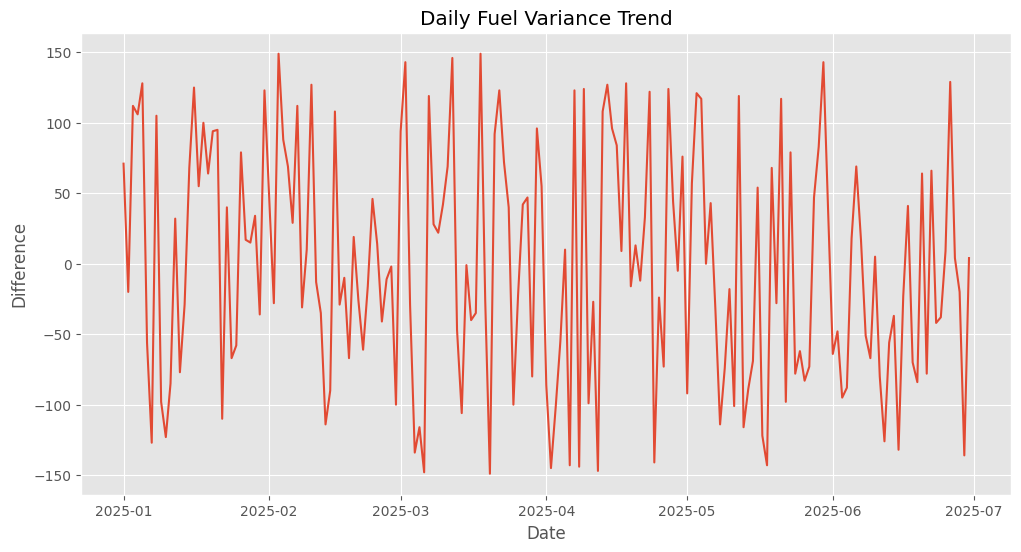

In [11]:
# Plot variance trend

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["difference"])

plt.title("Daily Fuel Variance Trend")

plt.xlabel("Date")

plt.ylabel("Difference")

plt.show()
 

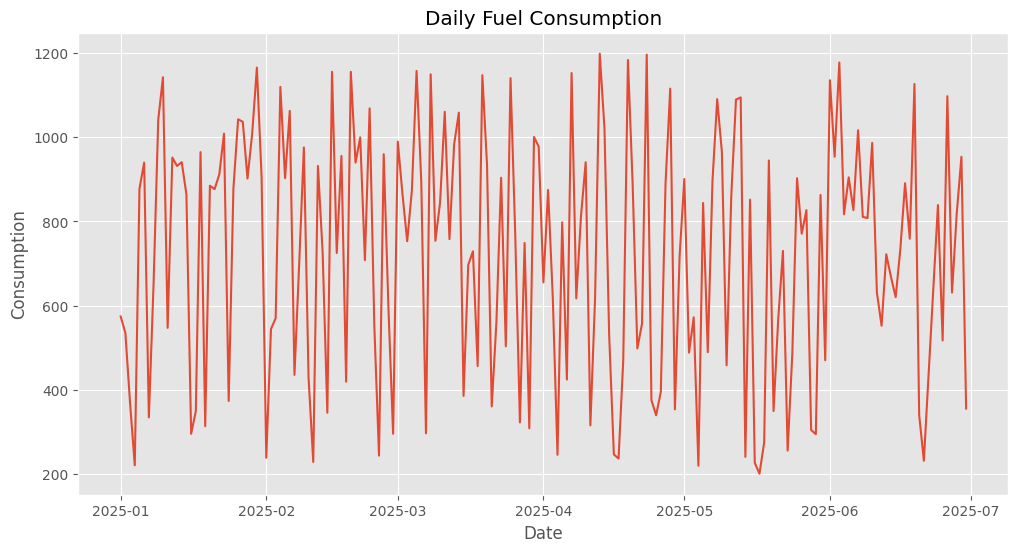

In [12]:
# Plot daily consumption
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["daily_consumption"])
plt.title("Daily Fuel Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

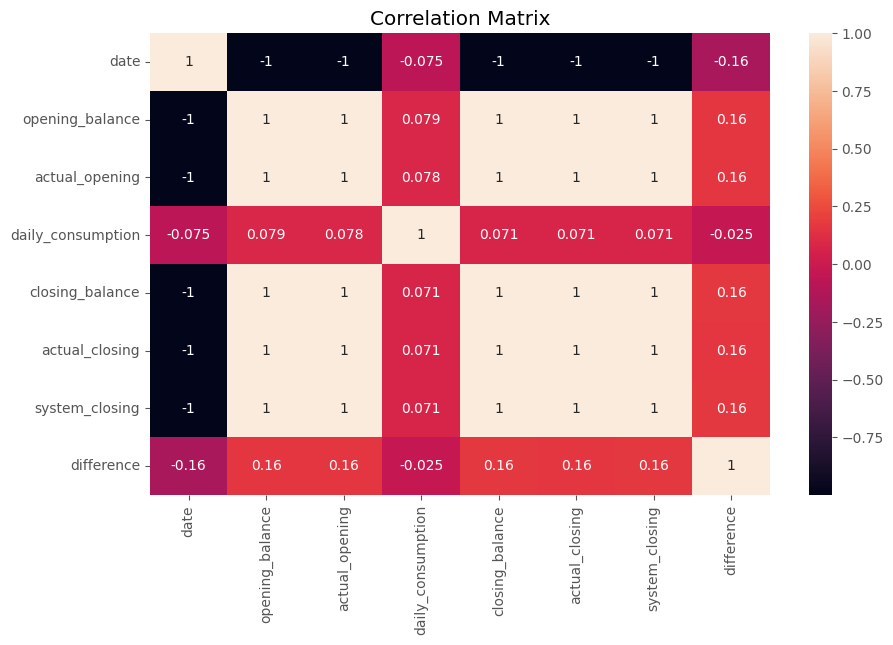

In [13]:
# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [14]:
# Basic insights
print("Maximum Variance:", df["difference"].max())
print("Minimum Variance:", df["difference"].min())
print("Average Variance:", df["difference"].mean())
print("Maximum Consumption:", df["daily_consumption"].max())
print("Average Consumption:", df["daily_consumption"].mean())

Maximum Variance: 149
Minimum Variance: -149
Average Variance: -0.8066298342541437
Maximum Consumption: 1199
Average Consumption: 723.8729281767955
